****
IMPORT
****

In [8]:
import os
import gc
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

****
FUSION DATASET
****

In [ ]:
RAW_DIR = "../data/raw/"
PROCESSED_DIR = "../data/processed/"

# Fonction pour le One-Hot Encoding (utilisée UNIQUEMENT pour les tables historiques)
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

print("🚀 Démarrage de la fusion (Méthode Hybride)...")

# --- 1. TABLE PRINCIPALE : LABEL ENCODING ---
print("1/6 Traitement de application_train.csv (Label Encoding)...")
df = pd.read_csv(os.path.join(RAW_DIR, "application_train.csv"))

# On identifie les colonnes de type 'object' (texte)
categorical_cols_main = [col for col in df.columns if df[col].dtype == 'object']

# On applique le Label Encoding
for col in categorical_cols_main:
    # pd.factorize renvoie un tuple (array_de_nombres, index_des_catégories)
    # On ne garde que le premier élément [0] qui contient les nombres.
    # Les NaN deviendront -1.
    df[col] = pd.factorize(df[col])[0] 

# --- 2. BUREAU : ONE-HOT ENCODING & AGRÉGATION ---
print("2/6 Traitement de bureau.csv...")
bureau = pd.read_csv(os.path.join(RAW_DIR, "bureau.csv"))
bureau, bureau_cat = one_hot_encoder(bureau)

bureau_aggregations = {}
for col in bureau.columns:
    if col not in ['SK_ID_CURR', 'SK_ID_BUREAU']:
        if col in bureau_cat:
            bureau_aggregations[col] = ['mean'] # Moyenne des statuts (One-Hot)
        else:
            bureau_aggregations[col] = ['min', 'max', 'mean', 'sum']

bureau_agg = bureau.groupby('SK_ID_CURR').agg(bureau_aggregations)
bureau_agg.columns = pd.Index(['BURO_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
del bureau, bureau_agg; gc.collect()

# --- 3. PREVIOUS APPLICATIONS ---
print("3/6 Traitement de previous_application.csv...")
prev = pd.read_csv(os.path.join(RAW_DIR, "previous_application.csv"))
prev, prev_cat = one_hot_encoder(prev)

prev_aggregations = {}
for col in prev.columns:
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']:
        if col in prev_cat:
            prev_aggregations[col] = ['mean']
        else:
            prev_aggregations[col] = ['min', 'max', 'mean', 'sum']

prev_agg = prev.groupby('SK_ID_CURR').agg(prev_aggregations)
prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')
del prev, prev_agg; gc.collect()

# --- 4. POS CASH BALANCE ---
print("4/6 Traitement de POS_CASH_balance.csv...")
pos = pd.read_csv(os.path.join(RAW_DIR, "POS_CASH_balance.csv"))
pos, pos_cat = one_hot_encoder(pos)

pos_aggregations = {}
for col in pos.columns:
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']:
        if col in pos_cat:
            pos_aggregations[col] = ['mean']
        else:
            pos_aggregations[col] = ['max', 'mean', 'size']

pos_agg = pos.groupby('SK_ID_CURR').agg(pos_aggregations)
pos_agg.columns = pd.Index(['POS_' + e[0] + "_" + e[1].upper() for e in pos_agg.columns.tolist()])
df = df.merge(pos_agg, on='SK_ID_CURR', how='left')
del pos, pos_agg; gc.collect()

# --- 5. INSTALLMENTS PAYMENTS ---
print("5/6 Traitement de installments_payments.csv...")
ins = pd.read_csv(os.path.join(RAW_DIR, "installments_payments.csv"))
ins, ins_cat = one_hot_encoder(ins)

# Features métiers
ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT'] 
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT'] 

ins_aggregations = {}
for col in ins.columns:
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']:
        ins_aggregations[col] = ['max', 'mean', 'sum', 'var']

ins_agg = ins.groupby('SK_ID_CURR').agg(ins_aggregations)
ins_agg.columns = pd.Index(['INSTAL_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
df = df.merge(ins_agg, on='SK_ID_CURR', how='left')
del ins, ins_agg; gc.collect()

# --- 6. CREDIT CARD BALANCE ---
print("6/6 Traitement de credit_card_balance.csv...")
cc = pd.read_csv(os.path.join(RAW_DIR, "credit_card_balance.csv"))
cc, cc_cat = one_hot_encoder(cc)

cc_aggregations = {}
for col in cc.columns:
    if col not in ['SK_ID_CURR', 'SK_ID_PREV']:
        if col in cc_cat:
            cc_aggregations[col] = ['mean']
        else:
            cc_aggregations[col] = ['max', 'mean', 'sum', 'var']

cc_agg = cc.groupby('SK_ID_CURR').agg(cc_aggregations)
cc_agg.columns = pd.Index(['CC_' + e[0] + "_" + e[1].upper() for e in cc_agg.columns.tolist()])
df = df.merge(cc_agg, on='SK_ID_CURR', how='left')
del cc, cc_agg; gc.collect()

# --- SAUVEGARDE FINALE ---
print("💾 Nettoyage des noms de colonnes et sauvegarde...")
# On nettoie les noms de colonnes pour LightGBM
df = df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

os.makedirs(PROCESSED_DIR, exist_ok=True)
df.to_parquet(os.path.join(PROCESSED_DIR, "dataset_train_fusion.parquet"))

print(f"✅ Terminé ! Le dataset final contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

🚀 Démarrage de la fusion (Méthode Hybride)...
1/6 Traitement de application_train.csv (Label Encoding)...
2/6 Traitement de bureau.csv...
3/6 Traitement de previous_application.csv...
4/6 Traitement de POS_CASH_balance.csv...
5/6 Traitement de installments_payments.csv...
6/6 Traitement de credit_card_balance.csv...
💾 Nettoyage des noms de colonnes et sauvegarde...
✅ Terminé ! Le dataset final contient 307511 lignes et 576 colonnes.


****
CHARGE DATASET
****

In [9]:
# 1. Charger la base de données consolidée
df = pd.read_parquet("../data/processed/dataset_train_fusion.parquet")

****
EXPLORATION
****

--- 1. LE DÉSÉQUILIBRE DES CLASSES ---
Pourcentage de défaut de paiement (Classe 1) : 8.07%
Pourcentage de bons clients (Classe 0) : 91.93%



C:\Users\Nérion\AppData\Local\Temp\ipykernel_39056\4006873020.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TARGET', palette='viridis')


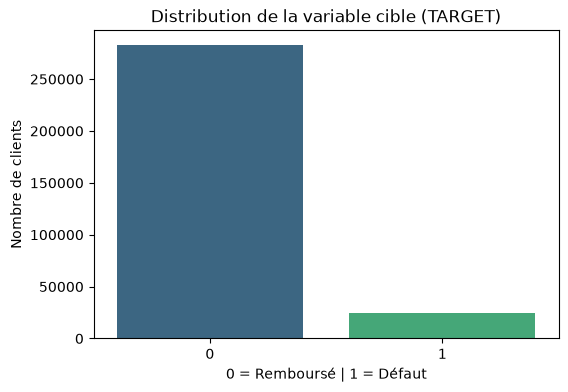

--- 2. LES VALEURS MANQUANTES (SPARSITY) ---
Colonnes avec > 50% de valeurs manquantes : 135 sur 576
Colonnes avec > 75% de valeurs manquantes : 27 sur 576

--- 3. LE TOP DES VARIABLES (CORRÉLATIONS) ---
Top 10 : Profils tendant vers le REMBOURSEMENT (Corrélations négatives) :
EXT_SOURCE_3                              -0.178919
EXT_SOURCE_2                              -0.160472
EXT_SOURCE_1                              -0.155317
BURO_CREDIT_ACTIVE_Closed_MEAN            -0.079369
PREV_CODE_REJECT_REASON_XAP_MEAN          -0.073930
PREV_NAME_CONTRACT_STATUS_Approved_MEAN   -0.063521
CC_MONTHS_BALANCE_VAR                     -0.058817
NAME_INCOME_TYPE                          -0.057020
CODE_GENDER                               -0.054718
INSTAL_DAYS_INSTALMENT_VAR                -0.052273
Name: TARGET, dtype: float64

----------------------------------

Top 10 : Profils tendant vers le DÉFAUT (Corrélations positives) :
PREV_CODE_REJECT_REASON_nan_MEAN                  NaN
PREV_NAME_CLIEN

In [2]:
print("--- 1. LE DÉSÉQUILIBRE DES CLASSES ---")
# Calcul du pourcentage de mauvais clients
target_mean = df['TARGET'].mean() * 100
print(f"Pourcentage de défaut de paiement (Classe 1) : {target_mean:.2f}%")
print(f"Pourcentage de bons clients (Classe 0) : {100 - target_mean:.2f}%\n")

# Affichage graphique
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='TARGET', palette='viridis')
plt.title('Distribution de la variable cible (TARGET)')
plt.ylabel('Nombre de clients')
plt.xlabel('0 = Remboursé | 1 = Défaut')
plt.show()

print("--- 2. LES VALEURS MANQUANTES (SPARSITY) ---")
# Calcul du pourcentage de NaN par colonne
missing_stats = df.isnull().sum() / len(df) * 100
missing_plus_50 = (missing_stats > 50).sum()
missing_plus_75 = (missing_stats > 75).sum()

print(f"Colonnes avec > 50% de valeurs manquantes : {missing_plus_50} sur {df.shape[1]}")
print(f"Colonnes avec > 75% de valeurs manquantes : {missing_plus_75} sur {df.shape[1]}\n")


print("--- 3. LE TOP DES VARIABLES (CORRÉLATIONS) ---")
# Quelles sont les variables les plus liées au fait de faire un défaut de paiement ?
# Attention : Le calcul de corrélation sur 576 colonnes peut prendre une petite minute !
correlations = df.corr()['TARGET'].sort_values()

print("Top 10 : Profils tendant vers le REMBOURSEMENT (Corrélations négatives) :")
print(correlations.head(10))
print("\n----------------------------------\n")
print("Top 10 : Profils tendant vers le DÉFAUT (Corrélations positives) :")
# On prend .tail(11) et on retire la dernière (qui est TARGET corrélée à TARGET = 1.0)
print(correlations.tail(11).iloc[:-1].sort_values(ascending=False))

`Observation`

Suite à la consolidation des différentes tables, l'analyse de notre dataset met en lumière trois points d'attention majeurs pour la suite du projet :

**1. Un déséquilibre des classes extrême (8% vs 92%)**
La grande majorité de nos clients remboursent leur crédit (92%). Ce déséquilibre implique qu'un modèle naïf prédisant systématiquement la classe 0 obtiendrait 92% d'exactitude (Accuracy). L'Accuracy n'est donc pas une métrique pertinente. Il sera indispensable d'utiliser des métriques adaptées (AUC, Recall) et d'appliquer une pénalité financière forte (score métier) pour forcer le modèle à détecter la minorité de mauvais payeurs.

**2. Une forte "Sparsity" (Valeurs manquantes)**
La fusion a généré un dataset très "creux" : 135 variables (sur 576) possèdent plus de 50% de valeurs manquantes (`NaN`). C'est un comportement normal lié à notre stratégie d'agrégation : si un client n'a pas d'historique de carte de crédit, toutes les colonnes associées sont vides. L'absence d'information étant une information en soi, nous ne supprimerons pas ces colonnes brutalement.

**3. Justification méthodologique du non-recours à l'imputation des NaN** repose sur trois fondements techniques et métier :

- Valeur informative de la donnée manquante (MNAR — Missing Not At Random) : Les NaN observés ne relèvent pas d'un défaut de saisie aléatoire, mais d'une réalité opérationnelle. L'absence d'historique dans les tables secondaires (bureau, POS_CASH_balance, credit_card_balance, etc.) traduit l'absence de certains produits financiers chez le client. Remplacer ces données par une valeur centrale inventerait un comportement financier fictif et éliminerait le signal propre à la non-détention d'un produit.

- Gestion native des valeurs manquantes par les modèles d'arbres (LightGBM / XGBoost) : L'algorithme LightGBM gère nativement les NaN via sa stratégie de division (optimal split direction). Lors de l'entraînement, pour chaque split sur une variable, l'algorithme assigne l'ensemble des observations ayant une valeur manquante vers la branche (gauche ou droite) qui minimise la perte globale, exploitant ainsi pleinement le signal du NaN sans altérer la distribution originale.

- Prévention du Data Leakage (fuite de données) : Toute imputation globale réalisée sur le dataset complet avant séparation des données contaminerait le jeu d'évaluation (Test set) avec des informations statistiques issues de l'ensemble de la population. Si une famille de modèles sensible aux NaN venait à être testée ultérieurement (ex. Régression Logistique), cette étape d'imputation serait alors encapsulée dans un Pipeline Scikit-Learn exécuté uniquement après le découpage des données.

**4. Validation du Feature Engineering**
Le top des corrélations montre que les variables externes de Home Credit (`EXT_SOURCE_1, 2 et 3`) sont les plus prédictives. Cependant, plusieurs variables issues de nos agrégations (ex: pourcentage de crédits passés approuvés ou clôturés) apparaissent dans le haut du classement. Cela confirme que l'historique bancaire apporte une vraie valeur ajoutée pour séparer les bons des mauvais profils.

****
CLEAN VALUE ABERRANT
****

In [10]:
# 1. Correction des anomalies
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
df['DAYS_EMPLOYED_ANOMALY'] = df['DAYS_EMPLOYED'].isnull().astype(int)

# 2. Conversion en années positives
df['YEARS_BIRTH'] = df['DAYS_BIRTH'] / -365
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

# 3. Écraser l'ancien fichier Parquet
df.to_parquet("../data/processed/dataset_train_fusion.parquet")

C:\Users\Nérion\AppData\Local\Temp\ipykernel_39056\3087448174.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
